IMPORTING LIBRARIES AND FRAMEWORKS

In [129]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from collections import Counter

DATA EXPLORATION

In [130]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [131]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [132]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [133]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [134]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [135]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


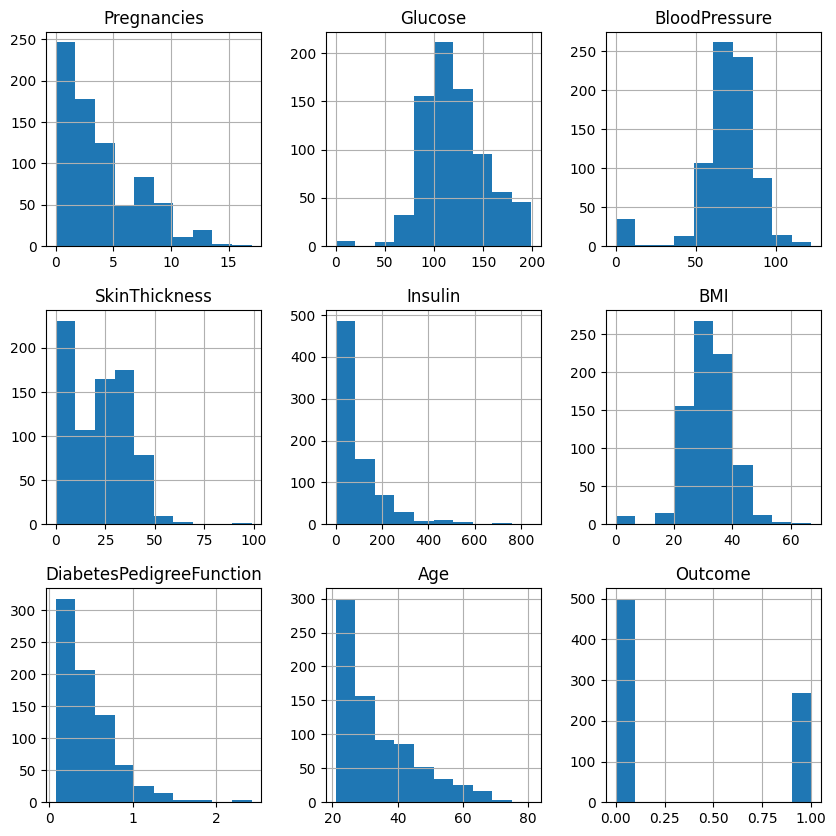

In [136]:
numerical_features = list(df.columns)
print(numerical_features)

df[numerical_features].hist(bins=10, figsize=(10, 10))
plt.savefig('Histogram plots')
plt.show()


<Axes: xlabel='Pregnancies'>

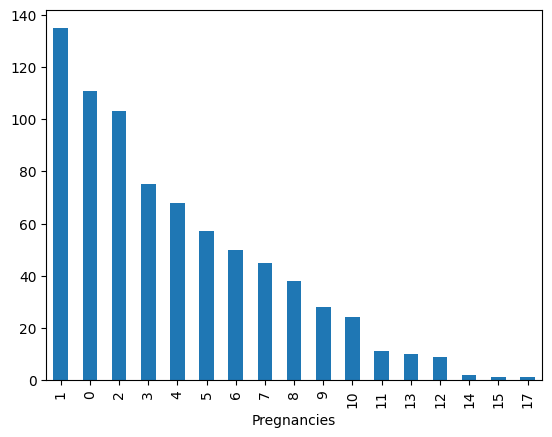

In [137]:
df['Pregnancies'].value_counts().plot(kind='bar')

<Axes: >

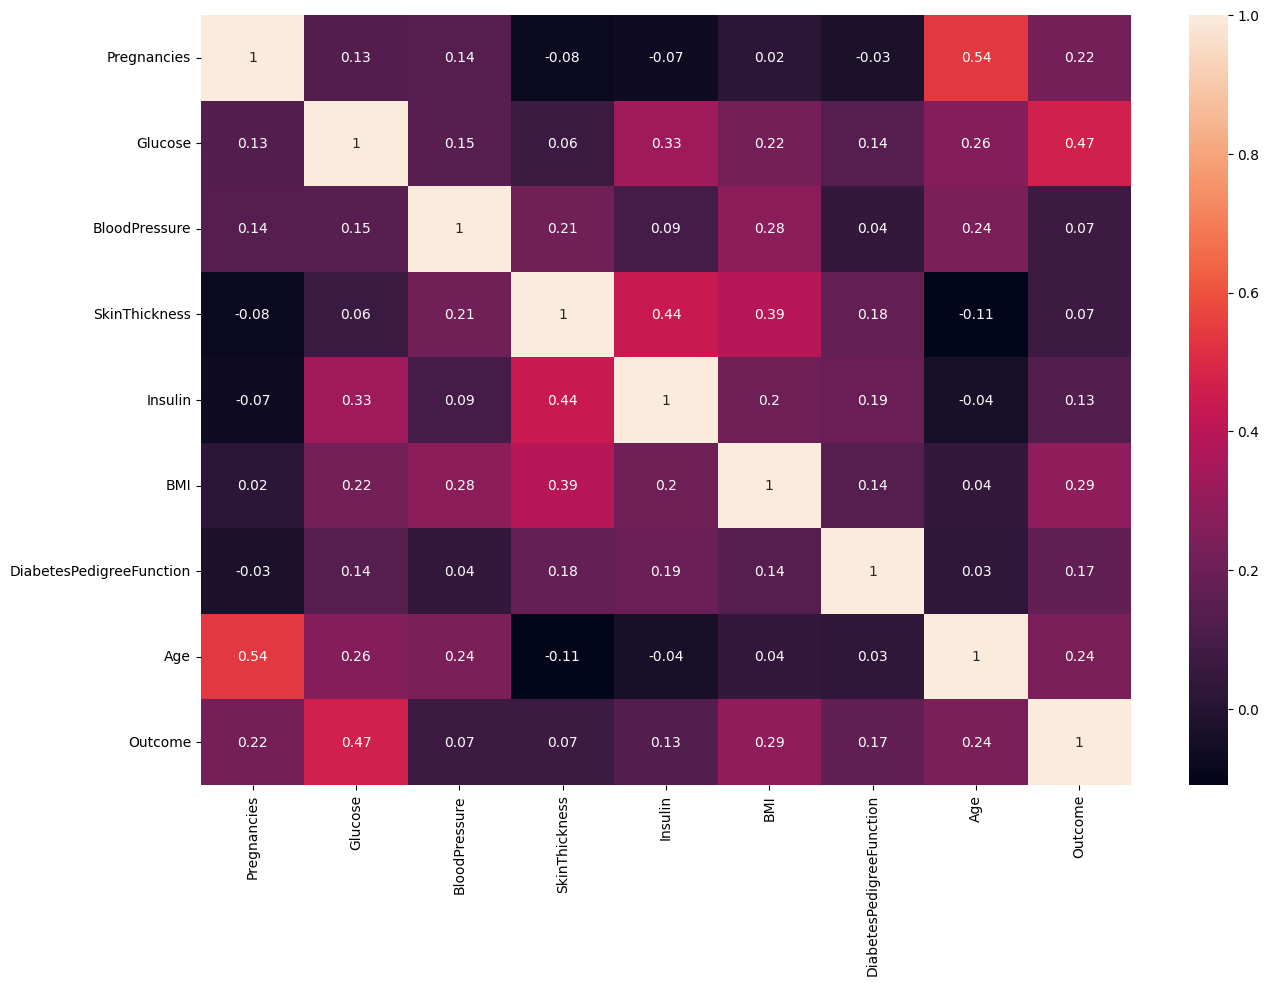

In [138]:
corr = df.corr(numeric_only=True).round(2)
plt.figure(figsize = (15,10))
sns.heatmap(corr, annot = True)

CHECKING FOR NULL VALUES

In [139]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

REPLACING 0 VALUES WITH THE MEDIAN

In [140]:
exclude_cols = ['Pregnancies', 'Outcome']

# Select columns to process (all except excluded ones)
cols_to_fix = [col for col in df.columns if col not in exclude_cols]

for col in cols_to_fix:
    if (df[col] == 0).any():  # only if column has 0
        median_value = df.loc[df[col] != 0, col].median()
        df.loc[df[col] == 0, col] = median_value

df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,125,33.6,0.627,50,1
1,1,85,66,29,125,26.6,0.351,31,0
2,8,183,64,29,125,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,29,125,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,72,29,125,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,29,125,32.3,0.232,54,1


SEPARATING THE TARGET VALUE AND THE INPUT VALUES

In [141]:
X = df.drop('Outcome', axis = 1)
print(X)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35      125  33.6   
1              1       85             66             29      125  26.6   
2              8      183             64             29      125  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27      125  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60             29      125  30.1   
767            1       93             70             31      125  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [142]:
y = df['Outcome']
print(y)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


DATA SEGREGATION: SPLITTING INTO TRAINING AND TESTING DATA SETS BEFORE USING SMOTE

In [143]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)
print("X_train Shape : ", X_train.shape)
print("X_test Shape  : ", X_test.shape)
print("y_train Shape : ", y_train.shape)
print("y_test Shape  : ", y_test.shape)
print(Counter(y_train))

X_train Shape :  (614, 8)
X_test Shape  :  (154, 8)
y_train Shape :  (614,)
y_test Shape  :  (154,)
Counter({0: 393, 1: 221})


PREPROCESSING THE DATA BEFORE IT IS TRAINED 

In [144]:
scaler = preprocessing.MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

DATA SEGREGATION: SPLITTING INTO TRAINING AND TESTING DATA SETS USING SMOTE

In [145]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
scaler = preprocessing.MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
oversampler = SMOTE()
X_train_sm, y_train_sm = oversampler.fit_resample(X_train, y_train)
print(Counter(y_train_sm))

Counter({1: 393, 0: 393})


LOGISTIC REGRESSION CLASSIFIER BEFORE SMOTE

[[98  9]
 [20 27]]


<Axes: >

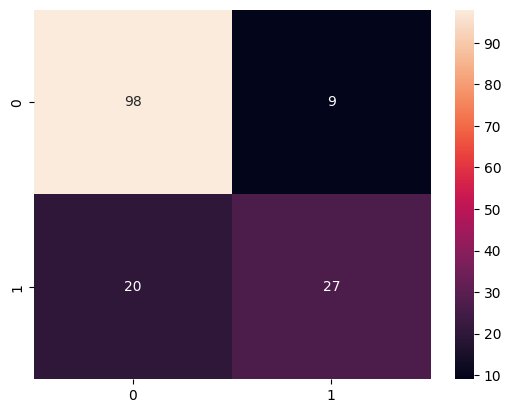

In [146]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

ylrpredict = lr.predict(X_test)

cm_lr = confusion_matrix(y_test, ylrpredict)
print(cm_lr)

sns.heatmap(cm_lr, annot=True)

In [147]:
cl_report_lr = classification_report(y_test, ylrpredict)
print(cl_report_lr)

ac_score_lr = accuracy_score(y_test, ylrpredict)
print(f"Accuracy Score: {ac_score_lr}")

f1_lr = f1_score(y_test, ylrpredict, average='weighted')
print(f'F1 Score: {f1_lr}')

              precision    recall  f1-score   support

           0       0.83      0.92      0.87       107
           1       0.75      0.57      0.65        47

    accuracy                           0.81       154
   macro avg       0.79      0.75      0.76       154
weighted avg       0.81      0.81      0.80       154

Accuracy Score: 0.8116883116883117
F1 Score: 0.8038130009214346


LOGISTIC REGRESSION USING SMOTE

[[86 21]
 [14 33]]


<Axes: >

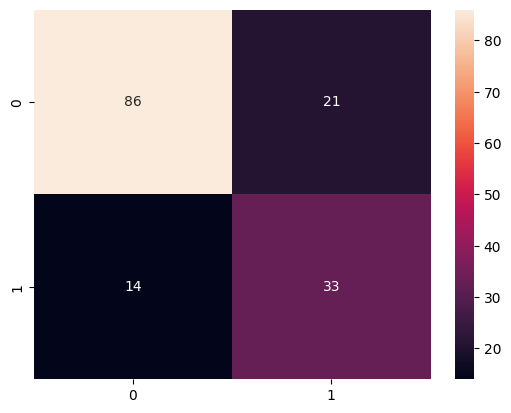

In [148]:
lr_sm = LogisticRegression(max_iter=1000)
lr_sm.fit(X_train_sm, y_train_sm)

ylrsmpredict = lr_sm.predict(X_test)

cm_lr = confusion_matrix(y_test, ylrsmpredict)
print(cm_lr)

sns.heatmap(cm_lr, annot=True)

In [203]:
cl_report_lr = classification_report(y_test, ylrsmpredict)
print(cl_report_lr)

ac_score_lr = accuracy_score(y_test, ylrsmpredict)
print(f"Accuracy Score: {ac_score_lr}")

f1_lr_sm = f1_score(y_test, ylrsmpredict, average='weighted')
print(f'F1 Score: {f1_lr_sm}')

              precision    recall  f1-score   support

           0       0.86      0.80      0.83       107
           1       0.61      0.70      0.65        47

    accuracy                           0.77       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.78      0.77      0.78       154

Accuracy Score: 0.7727272727272727
F1 Score: 0.7767602847241246


RANDOM FOREST CLASSIFIER BEFORE USING SMOTE

[[93 14]
 [15 32]]


<Axes: >

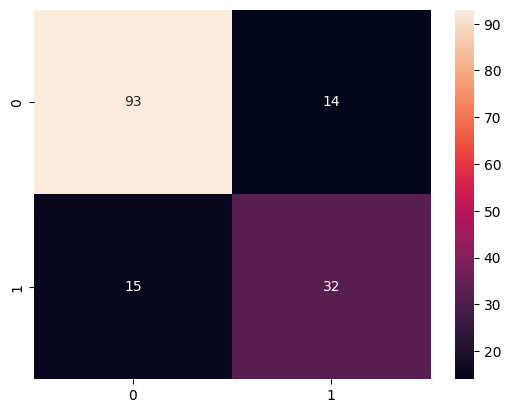

In [165]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
yrfpredict = rf.predict(X_test)

cm_rf = confusion_matrix(y_test, yrfpredict)
print(cm_rf)

sns.heatmap(cm_rf, annot=True)

In [151]:
cl_report_rf = classification_report(y_test, yrfpredict)
print(cl_report_rf)

ac_score_rf = accuracy_score(y_test, yrfpredict)
print(f"Accuracy Score: {ac_score_rf}")

f1_rf = f1_score(y_test, yrfpredict, average='weighted')
print(f'F1 Score: {f1_rf}')

              precision    recall  f1-score   support

           0       0.85      0.87      0.86       107
           1       0.69      0.66      0.67        47

    accuracy                           0.81       154
   macro avg       0.77      0.76      0.77       154
weighted avg       0.80      0.81      0.80       154

Accuracy Score: 0.8051948051948052
F1 Score: 0.8039792333270596


RANDOM FOREST CLASSIFIER USING SMOTE

[[89 18]
 [12 35]]


<Axes: >

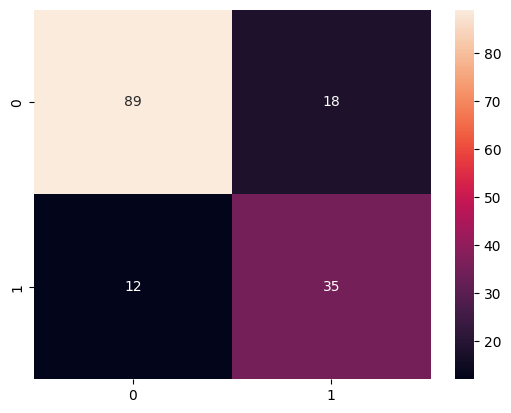

In [166]:
rf_sm = RandomForestClassifier()
rf_sm.fit(X_train_sm, y_train_sm)
yrfsmpredict = rf_sm.predict(X_test)

cm_rf = confusion_matrix(y_test, yrfsmpredict)
print(cm_rf)

sns.heatmap(cm_rf, annot=True)

In [204]:
cl_report_rf = classification_report(y_test, yrfsmpredict)
print(cl_report_rf)

ac_score_rf = accuracy_score(y_test, yrfsmpredict)
print(f"Accuracy Score: {ac_score_rf}")

f1_rf_sm = f1_score(y_test, yrfsmpredict, average='weighted')
print(f'F1 Score: {f1_rf_sm}')

              precision    recall  f1-score   support

           0       0.88      0.83      0.86       107
           1       0.66      0.74      0.70        47

    accuracy                           0.81       154
   macro avg       0.77      0.79      0.78       154
weighted avg       0.81      0.81      0.81       154

Accuracy Score: 0.8051948051948052
F1 Score: 0.8082292707292706


DECISION TREE CLASSIFIER BEFORE USING SMOTE

[[84 23]
 [21 26]]


<Axes: >

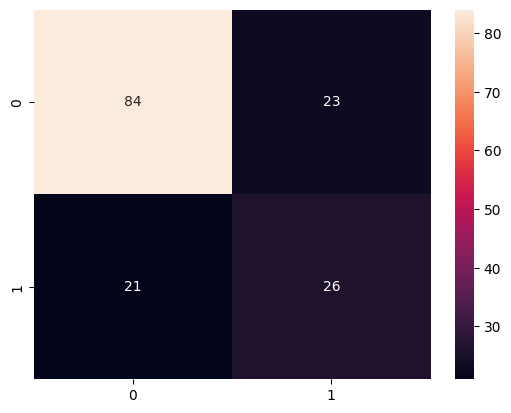

In [179]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
ydtpredict = dt.predict(X_test)

cm_dt = confusion_matrix(y_test, ydtpredict)
print(cm_dt)

sns.heatmap(cm_dt, annot=True)

In [187]:
cl_report_dt = classification_report(y_test, ydtpredict)
print(cl_report_dt)

ac_score_dt = accuracy_score(y_test, ydtpredict)
print(f"Accuracy Score: {ac_score_dt}")

f1_dt = f1_score(y_test, ydtpredict, average='weighted')
print(f'F1 Score: {f1_dt}')

              precision    recall  f1-score   support

           0       0.80      0.79      0.79       107
           1       0.53      0.55      0.54        47

    accuracy                           0.71       154
   macro avg       0.67      0.67      0.67       154
weighted avg       0.72      0.71      0.72       154

Accuracy Score: 0.7142857142857143
F1 Score: 0.715914195867026


DECISION TREE CLASSIFIER USING SMOTE

[[86 21]
 [14 33]]


<Axes: >

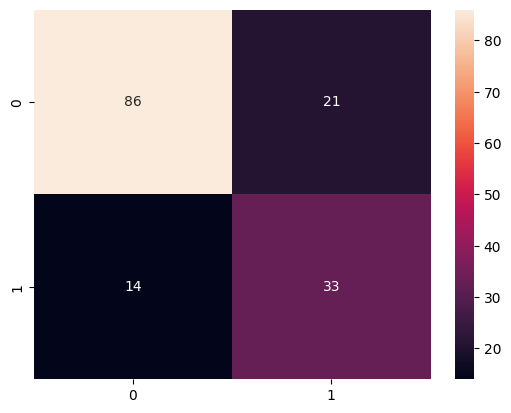

In [182]:
dt_sm = DecisionTreeClassifier()
dt_sm.fit(X_train_sm, y_train_sm)
ydtsmpredict = dt_sm.predict(X_test)

cm_dt = confusion_matrix(y_test, ydtsmpredict)
print(cm_dt)

sns.heatmap(cm_dt, annot=True)

In [205]:
cl_report_dt = classification_report(y_test, ydtsmpredict)
print(cl_report_dt)

ac_score_dt = accuracy_score(y_test, ydtsmpredict)
print(f"Accuracy Score: {ac_score_dt}")

f1_dt_sm = f1_score(y_test, ydtsmpredict, average='weighted')
print(f'F1 Score: {f1_dt_sm}')

              precision    recall  f1-score   support

           0       0.86      0.80      0.83       107
           1       0.61      0.70      0.65        47

    accuracy                           0.77       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.78      0.77      0.78       154

Accuracy Score: 0.7727272727272727
F1 Score: 0.7767602847241246


KNN CLASSIFIER BEFORE USING SMOTE

[[89 18]
 [16 31]]


<Axes: >

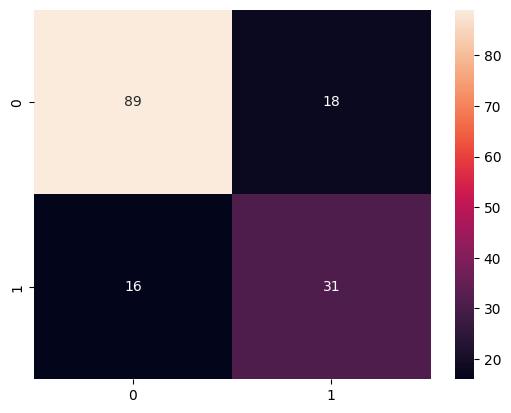

In [191]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
yknnpredict = knn.predict(X_test)

cm_knn = confusion_matrix(y_test, yknnpredict)
print(cm_knn)

sns.heatmap(cm_knn, annot=True)

In [ ]:
cl_report_knn = classification_report(y_test, yknnpredict)
print(cl_report_knn)

ac_score_knn = accuracy_score(y_test, yknnpredict)
print(f"Accuracy Score: {ac_score_knn}")

f1_knn = f1_score(y_test, yknnpredict, average='weighted')
print(f'F1 Score: {f1_knn}')

              precision    recall  f1-score   support

           0       0.85      0.83      0.84       107
           1       0.63      0.66      0.65        47

    accuracy                           0.78       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.78      0.78      0.78       154

Accuracy Score: 0.7792207792207793
F1 Score: 0.7804791513517929


KNN CLASSIFIER USING SMOTE

[[73 34]
 [12 35]]


<Axes: >

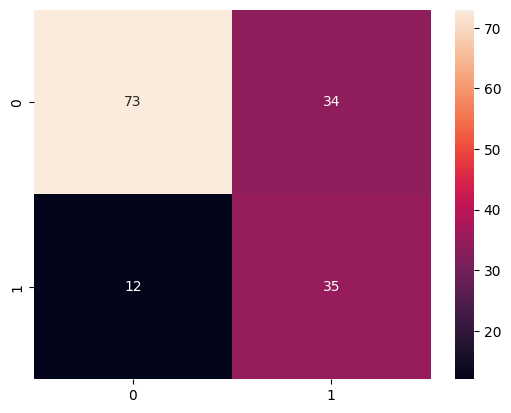

In [197]:
knn_sm = KNeighborsClassifier()
knn_sm.fit(X_train_sm, y_train_sm)
yknn_smpredict = knn_sm.predict(X_test)

cm_knn = confusion_matrix(y_test, yknn_smpredict)
print(cm_knn)

sns.heatmap(cm_knn, annot=True)

In [206]:
cl_report_knn = classification_report(y_test, yknn_smpredict)
print(cl_report_knn)

ac_score_knn = accuracy_score(y_test, yknn_smpredict)
print(f"Accuracy Score: {ac_score_knn}")

f1_knn_sm = f1_score(y_test, yknn_smpredict, average='weighted')
print(f'F1 Score: {f1_knn_sm}')

              precision    recall  f1-score   support

           0       0.86      0.68      0.76       107
           1       0.51      0.74      0.60        47

    accuracy                           0.70       154
   macro avg       0.68      0.71      0.68       154
weighted avg       0.75      0.70      0.71       154

Accuracy Score: 0.7012987012987013
F1 Score: 0.7125107292133154


X GRADIENT BOOST CLASSIFIER BEFORE USING SMOTE

[[94 13]
 [14 33]]


<Axes: >

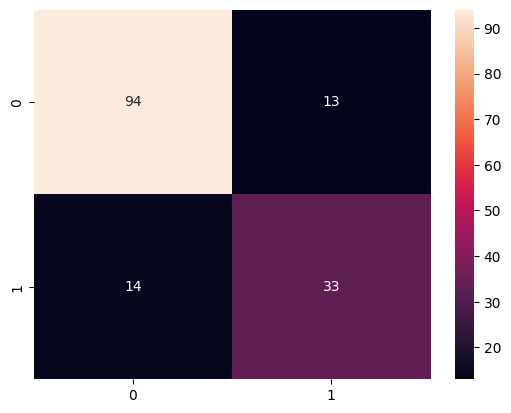

In [159]:
xgb = GradientBoostingClassifier()
xgb.fit(X_train, y_train)
ygbpredict = xgb.predict(X_test)

cm_xgb = confusion_matrix(y_test, ygbpredict)
print(cm_xgb)

sns.heatmap(cm_xgb, annot=True)

In [160]:
cl_report_xgb = classification_report(y_test, ygbpredict)
print(cl_report_xgb)

ac_score_xgb = accuracy_score(y_test, ygbpredict)
print(f"Accuracy Score: {ac_score_xgb}")

f1_xgb = f1_score(y_test, ygbpredict, average='weighted')
print(f'F1 Score: {f1_xgb}')

              precision    recall  f1-score   support

           0       0.87      0.88      0.87       107
           1       0.72      0.70      0.71        47

    accuracy                           0.82       154
   macro avg       0.79      0.79      0.79       154
weighted avg       0.82      0.82      0.82       154

Accuracy Score: 0.8246753246753247
F1 Score: 0.82414045069709


X GRADIENT BOOST CLASSIFIER USING SMOTE

[[84 23]
 [12 35]]


<Axes: >

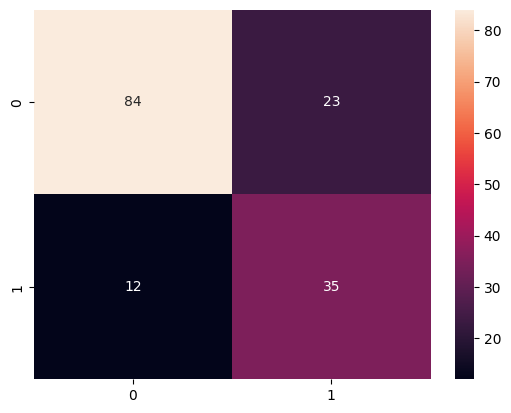

In [199]:
xgb_sm = GradientBoostingClassifier()
xgb_sm.fit(X_train_sm, y_train_sm)
ygb_sm_predict = xgb_sm.predict(X_test)

cm_xgb = confusion_matrix(y_test, ygb_sm_predict)
print(cm_xgb)

sns.heatmap(cm_xgb, annot=True)

In [207]:
cl_report_xgb = classification_report(y_test, ygb_sm_predict)
print(cl_report_xgb)

ac_score_xgb = accuracy_score(y_test, ygb_sm_predict)
print(f"Accuracy Score: {ac_score_xgb}")

f1_xgb_sm = f1_score(y_test, ygb_sm_predict, average='weighted')
print(f'F1 Score: {f1_xgb_sm}')

              precision    recall  f1-score   support

           0       0.88      0.79      0.83       107
           1       0.60      0.74      0.67        47

    accuracy                           0.77       154
   macro avg       0.74      0.76      0.75       154
weighted avg       0.79      0.77      0.78       154

Accuracy Score: 0.7727272727272727
F1 Score: 0.7784743991640543


SUPPORT VECTOR MACHINE CLASSIFIER BEFORE USING SMOTE

[[96 11]
 [24 23]]


<Axes: >

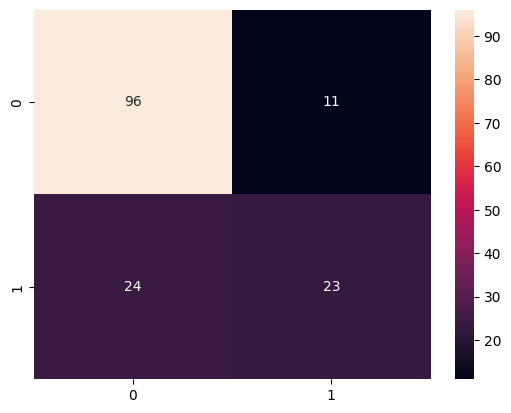

In [161]:
svm = SVC()
svm.fit(X_train, y_train)
ysvmpredict = svm.predict(X_test)

cm_svm = confusion_matrix(y_test, ysvmpredict)
print(cm_svm)

sns.heatmap(cm_svm, annot=True)

In [209]:
cl_report_svm = classification_report(y_test, ysvmpredict)
print(cl_report_svm)

ac_score_svm = accuracy_score(y_test, ysvmpredict)
print(f"Accuracy Score: {ac_score_svm}")

f1_svm = f1_score(y_test, ysvmpredict, average='weighted')
print(f'F1 Score: {f1_svm}')

              precision    recall  f1-score   support

           0       0.80      0.90      0.85       107
           1       0.68      0.49      0.57        47

    accuracy                           0.77       154
   macro avg       0.74      0.69      0.71       154
weighted avg       0.76      0.77      0.76       154

Accuracy Score: 0.7727272727272727
F1 Score: 0.7609971471939166


SUPPORT VECTOR MACHINE USING SMOTE

[[83 24]
 [12 35]]


<Axes: >

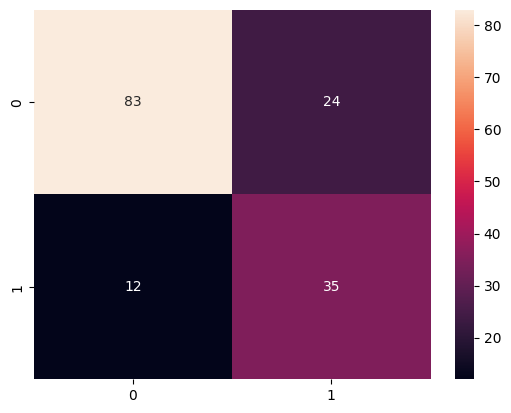

In [201]:
svm_sm = SVC()
svm_sm.fit(X_train_sm, y_train_sm)
ysvm_smpredict = svm_sm.predict(X_test)

cm_svm = confusion_matrix(y_test, ysvm_smpredict)
print(cm_svm)

sns.heatmap(cm_svm, annot=True)

In [212]:
cl_report_svm = classification_report(y_test, ysvm_smpredict)
print(cl_report_svm)

ac_score_svm = accuracy_score(y_test, ysvm_smpredict)
print(f"Accuracy Score: {ac_score_svm}")

f1_svm_sm = f1_score(y_test, ysvm_smpredict, average='weighted')
print(f'F1 Score: {f1_svm_sm}')

              precision    recall  f1-score   support

           0       0.87      0.78      0.82       107
           1       0.59      0.74      0.66        47

    accuracy                           0.77       154
   macro avg       0.73      0.76      0.74       154
weighted avg       0.79      0.77      0.77       154

Accuracy Score: 0.7662337662337663
F1 Score: 0.7725222657036592


In [163]:
models = ['Logistic Regression', 'Decision Tree', 'K Nearest Neighbour', 'Random Forest', 'Gradient Boosting', 'Support Vector Machine']
F1_Score = [f1_lr, f1_dt, f1_knn, f1_rf, f1_xgb, f1_svm]
compare_models = pd.DataFrame({'Algorithms': models, 'F1 Score': F1_Score})
compare_models.sort_values(by = 'F1 Score', ascending=False)

,Algorithms,F1 Score
4,Gradient Boosting,0.824140
3,Random Forest,0.805195
2,K Nearest Neighbour,0.780479
0,Logistic Regression,0.776760
5,Support Vector Machine,0.760997
1,Decision Tree,0.723112


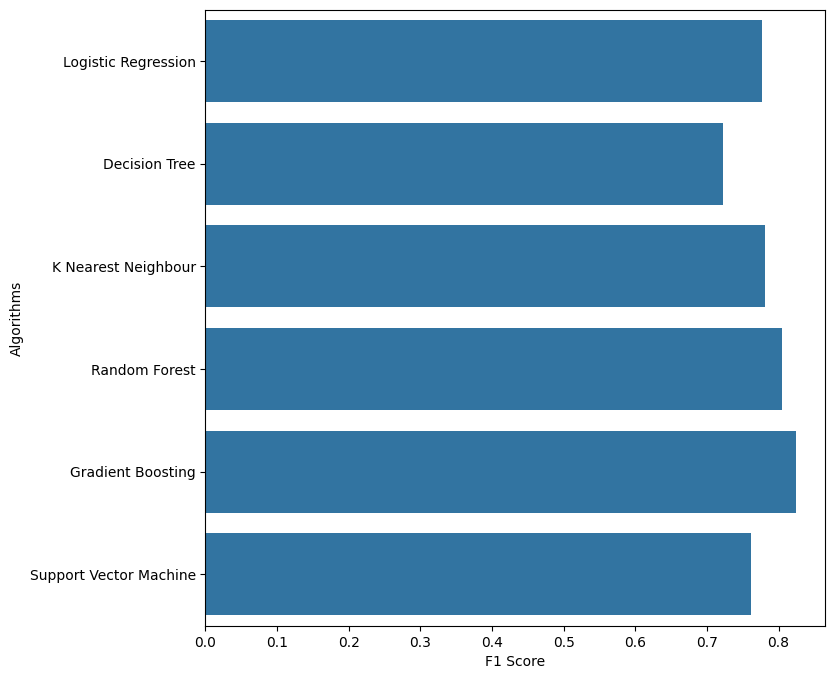

In [164]:
plt.figure(figsize=(8,8))
sns.barplot(x = 'F1 Score', y = 'Algorithms', data = compare_models)
plt.show()

In [215]:
models = ['Logistic Regression', 'Decision Tree', 'K Nearest Neighbour', 'Random Forest', 'Gradient Boosting', 'Support Vector Machine']
F1_Score_sm = [f1_lr_sm, f1_dt_sm, f1_knn_sm, f1_rf_sm, f1_xgb_sm, f1_svm_sm]
compare_models_sm = pd.DataFrame({'Algorithms': models, 'F1 Score': F1_Score_sm})
compare_models_sm.sort_values(by = 'F1 Score', ascending=False)

,Algorithms,F1 Score
3,Random Forest,0.808229
4,Gradient Boosting,0.778474
0,Logistic Regression,0.776760
1,Decision Tree,0.776760
5,Support Vector Machine,0.772522
2,K Nearest Neighbour,0.712511


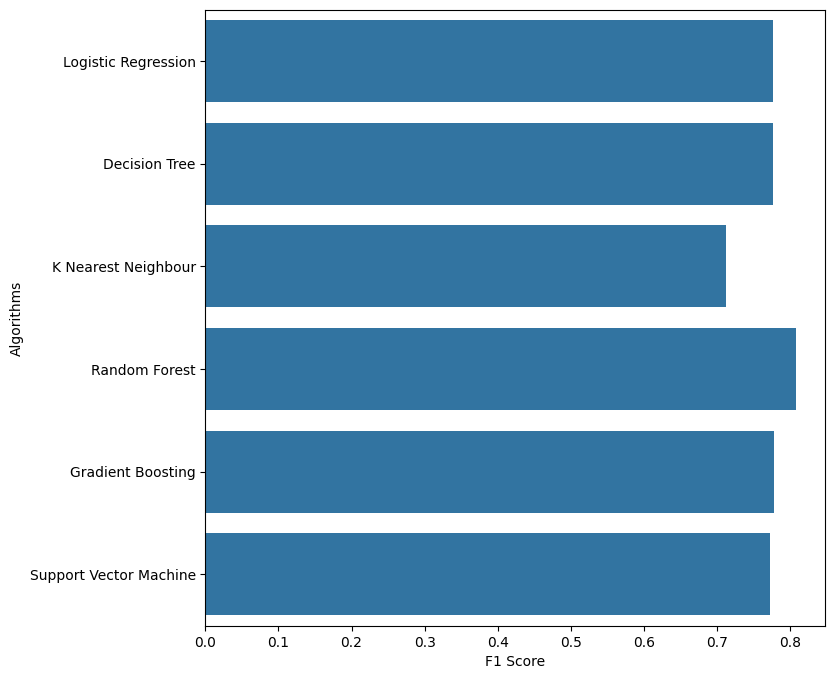

In [216]:
plt.figure(figsize=(8,8))
sns.barplot(x = 'F1 Score', y = 'Algorithms', data = compare_models_sm)
plt.show()